# Archaeological objects and their chemical composition 

During recent survey of an archaeological site in East Africa called Kilwa, researchers found huge volumes of iron slag. This is a material that forms as a byproduct during iron production and is usually discarded.

Following preliminary examination, archaeologists proposed a hypothesis that two different steps of the production process were taking place at the site.

In order to test this hypothesis, samples of iron slag were collected and analysed to obtain information about their chemical composition. Different technological processes lead to iron slag having distinct chemical compositions.

The goal of this project is to carry out principal component analysis of the chemical information to determine whether the archaeologists are right. The analysis should reveal whether one, two, or more distinct clusters are visible in the PCA plot.

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

## Data loading and cleaning

First, let's import the necessary packages.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q1. Use `pandas` to load the `kilwa_site_data.csv` dataset (found in the data/ folder) into a DataFrame, and look at the first 10 rows. Store the dataset under variable `data`**.

In [25]:
# Your code here...
data = pd.read_csv('data/kilwa_site_data.csv')
data.head(10)

,Sample,Site,Sodium,Oxygen,Magnesium,Potassium,Calcium,Titanium,Iron,Aluminium,...,Strontium,Copper,Nickel,Sulfur,Phosphorus,Rhodium,Tin,Chromium,Arsenic,Zinc
0,EB005,Kilwa,1.20768,1.600000e-06,0.094387,0.000000,3.134449,0.176351,74.210419,1.834800,...,0.027355,0.000713,0.006769,0.807874,0.867509,0,0.00000,0.0,0.0,0.0
1,EB005,Kilwa,0.00000,7.140000e-08,0.077279,0.112684,1.701345,0.150296,78.902044,1.338994,...,0.017984,0.000000,0.000000,0.031357,0.042061,0,0.00000,0.0,0.0,0.0
2,EB005,Kilwa,0.00000,-1.300000e-06,0.166517,0.261423,2.038331,0.124420,76.549931,1.498002,...,0.026264,0.000000,0.000000,0.038252,0.065478,0,0.00000,0.0,0.0,0.0
3,EB005,Kilwa,0.00000,3.850000e-07,0.111906,0.164109,1.555043,0.175369,77.464105,1.222445,...,0.019069,0.023835,0.000000,0.004183,0.044562,0,0.00000,0.0,0.0,0.0
4,EB005,Kilwa,0.00000,-1.190000e-06,0.107345,0.443995,2.773370,0.160835,75.382715,2.178886,...,0.033115,0.024863,0.000000,0.064500,0.040204,0,0.02025,0.0,0.0,0.0
5,EB005,Kilwa,0.00000,4.630000e-09,0.118816,0.434789,3.875111,0.188014,74.482809,2.382049,...,0.056796,0.007780,0.000000,0.035393,0.090572,0,0.00000,0.0,0.0,0.0
6,EB005,Kilwa,0.00000,5.280000e-08,0.071439,0.341861,4.396350,0.120509,73.690668,1.545310,...,0.039254,0.020437,0.002422,0.054152,0.046076,0,0.00000,0.0,0.0,0.0
7,EB005,Kilwa,0.00000,-1.620000e-06,0.215417,0.318849,5.331294,0.120079,70.587479,1.551726,...,0.038013,0.000392,0.000000,0.034409,0.051757,0,0.00000,0.0,0.0,0.0
8,EB005,Kilwa,0.00000,2.440000e-06,0.373711,0.212581,6.600972,0.101754,65.099005,1.360731,...,0.031939,0.003489,0.000000,0.225348,0.387406,0,0.00000,0.0,0.0,0.0
9,EB005,Kilwa,0.00000,-3.170000e-06,0.040159,0.510632,3.579475,0.249242,75.850214,2.547156,...,0.055364,0.008966,0.000000,0.050464,0.107273,0,0.00000,0.0,0.0,0.0


You will notice that the first two columns contain information about the sample and the site the objects were found at. The remaining rows contain quantitative elemental information about the samples. Let's start by inspecting the dataset. Look at the `.info()` of the dataset to see if there are any null values.

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sample      149 non-null    str    
 1   Site        149 non-null    str    
 2   Sodium      149 non-null    float64
 3   Oxygen      149 non-null    float64
 4   Magnesium   149 non-null    float64
 5   Potassium   149 non-null    float64
 6   Calcium     149 non-null    float64
 7   Titanium    149 non-null    float64
 8   Iron        149 non-null    float64
 9   Aluminium   149 non-null    float64
 10  Silicon     149 non-null    float64
 11  Lead        149 non-null    float64
 12  Manganese   149 non-null    float64
 13  Chlorine    149 non-null    float64
 14  Silver      149 non-null    float64
 15  Gold        149 non-null    float64
 16  Barium      149 non-null    float64
 17  Strontium   149 non-null    float64
 18  Copper      149 non-null    float64
 19  Nickel      149 non-null    float64
 20 

**Q2. Store the first column, containing sample information, as a `pandas Series` type variable called `sample_list`.**


_Hint: You can check the datatype of a variable by using the in-built python function `type()`, e.g. `type(sample_list)`. The precise datatype of a `pandas Series` is `pandas.core.series.Series`._

In [27]:
# Your code here...
sample_list = data['Sample']

**Q3. Further cleaning**

* Make a copy of `data` called `cleaned_data` using the `.copy()` method.
* Drop any non-numeric columns from `cleaned_data`.
* Remove any columns that contain only zeros from `cleaned_data`, as these contain no valuable information.

_Hint: You may find the [`pandas` function `.any()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html) useful for removing columns containing only zeros._

In [28]:
# Your code here...
cleaned_data = data.copy()
cleaned_data = cleaned_data.select_dtypes(include='number')
cleaned_data = cleaned_data.loc[:, cleaned_data.any()]

## PCA 


Let's make sure we have the necessary packages for PCA.
Import `preprocessing` from `sklearn`, and `PCA` from `sklearn.decomposition`.

In [29]:
from sklearn import preprocessing
from sklearn.decomposition import PCA

**Q4. Before doing the PCA, centre and scale `cleaned_data` using [`preprocessing.scale()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html). Store the scaled data as `scaled_data`.**

In [30]:
# Your code here...
scaled_data = preprocessing.scale(cleaned_data)

**Q5. Instantiate a `PCA` object with the variable name `pca`, and fit it to `scaled_data`.**

In [31]:
# Your code here...
pca = PCA()
pca.fit(scaled_data)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

**Q6. How much variance do the first two components explain? Calculate the sum of the `pca.explained_variance_ratio_` for the first two components and store the result as `expl_var`.**

In [32]:
# Your code here...
expl_var = pca.explained_variance_ratio_[:2].sum()
expl_var

np.float64(0.46507177067197913)

**Q7. Transform the `scaled_data` and store the outcome as `pca_data`.**

In [33]:
# Your code here...
pca_data = pca.transform(scaled_data)

**Q8. Create a `pd.DataFrame` of `pca_data` setting its index as `sample_list` which we stored earlier. Save this DataFrame as `pca_df`.**

In [34]:
# Your code here...
pca_df = pd.DataFrame(pca_data, index=sample_list)

Take a look at `pca_df` by running the cell below. Each column of the DataFrame is the number of a principal component.

In [35]:
pca_df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
Sample,,,,,,,,,,,,,,,,,,,,,
EB005,-3.495169,0.243190,0.784297,3.942873,-3.310697,6.284095,-1.464852,0.639260,-1.890832,1.126820,...,-0.453668,-0.351047,-0.488436,0.015330,0.195698,0.300550,-0.517711,-0.121189,0.009691,-1.819353e-10
EB005,-5.284807,0.868301,-1.365226,-1.344089,0.223755,-0.188567,-1.153522,0.800614,-0.703087,-0.468624,...,1.168025,0.015413,-0.274737,0.290979,0.162386,-0.359746,-0.134857,0.325408,0.078026,-7.680437e-11
EB005,-5.201163,1.080906,-1.008327,-0.233257,0.223904,-1.146125,-1.139293,1.144187,-2.015506,-0.974662,...,1.097785,0.200440,-0.595642,0.222648,0.203020,-0.616121,0.083985,0.227360,-0.042062,2.181431e-10
EB005,-5.772982,0.297227,0.958711,1.758177,0.160960,-1.618158,-1.683819,-0.181453,-0.019367,-1.102307,...,-0.503443,-0.459347,-1.153361,0.092350,-0.338901,-0.262732,-0.006916,0.433056,-0.064944,-2.214634e-10
EB005,-5.399076,-0.515954,1.542551,1.284042,1.672614,-2.046590,-0.689911,-0.035442,-1.298997,2.464619,...,2.398021,0.575657,0.448360,0.094074,0.191027,-0.631509,0.337904,0.015380,0.003414,8.240020e-10


**Q9. Make a copy of `pca_df` named `pca_table` using `.copy()`, and rename the columns of `pca_table`, adding 'PC' to the beginning of each column name (`['PC1', 'PC2', 'PC3', 'PC4', 'PC5'...]`).**

In [36]:
# Your code here...
pca_table = pca_df.copy()
pca_table.columns = ['PC' + str(i + 1) for i in range(pca_table.shape[1])]

## Plotting

Run the cell below to create a colour palette to be used for plotting.

In [37]:
ID_palette = {}
for i in np.unique(pca_table.index):
    if i in ['EB005', 'EB009', 'EB023', 'EB036']:
        ID_palette[i] = "#A5C93D"  
    else:
        ID_palette[i] = "#8B006B"
ID_palette

{'EB005': '#A5C93D',
 'EB008': '#8B006B',
 'EB009': '#A5C93D',
 'EB017': '#8B006B',
 'EB018': '#8B006B',
 'EB023': '#A5C93D',
 'EB028': '#8B006B',
 'EB030': '#8B006B',
 'EB033': '#8B006B',
 'EB034': '#8B006B',
 'EB035': '#8B006B',
 'EB036': '#A5C93D',
 'EB037': '#8B006B',
 'EB038': '#8B006B',
 'EB040': '#8B006B'}

**Q10. Use `seaborn` to plot the first _two_ principal components in a scatterplot.**

- Set `hue` to `pca_table.index`
- Set `palette` to `ID_palette`
- Plot both directions of the PCA. Since `data` was `pca.transform`ed from data axes to principal axes, PCA directions correspond to coordinate axes.

In other words, add a horizontal line, passing through `0, 0` that extends the full width of the graph, and a vertical line, passing through `0, 0`, that extends the full height of the graph.

_Hint: Use the `matplotlib.pyplot` (which we imported earlier as `plt`) [`.plot()` method](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to draw these additional lines._

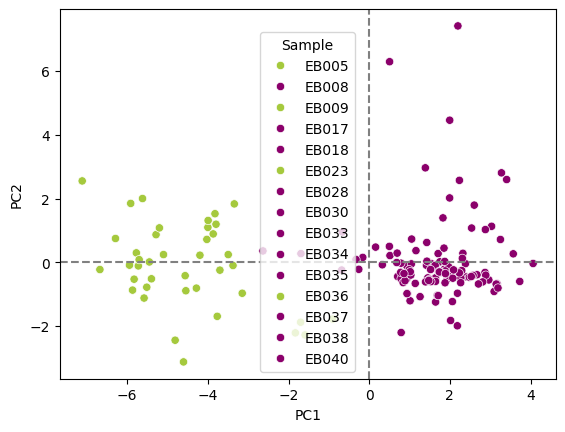

In [38]:
# Your code here...
sns.scatterplot(x='PC1', y='PC2', data=pca_table, hue=pca_table.index, palette=ID_palette)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

## PCA and plotting of transposed data

In archaeological science it is common practice to transpose the dataset and perform PCA with elements set as the index. In other words, rather than have a row per sample and a column for each element, it is preferred to have a row per element and a column for each sample.

**Q11. Transpose the `cleaned_data` and store this converted dataset as `transposed_data`.**

In [39]:
# Your code here...
transposed_data = cleaned_data.T

**Q12. Based on the code you wrote earlier, create a function called `PCA_transformed_table` that:**


* Takes a dataset as an argument
* Scales the dataset
* Instantiates a PCA model
* Fits and transforms the scaled dataset
* Converts the fitted and transformed dataset to a `pd.DataFrame` using the index of the supplied dataset as the index
* Renames the columns from 0, 1, 2... to PC1, PC2, PC3...
* Returns this processed DataFrame.

Call the `PCA_transformed_table` function supplying `transposed_data` as an argument and storing the returned `pd.DataFrame` as `t_pca_table`.

In [40]:
# Your code here...
def PCA_transformed_table(data):
    scaled = preprocessing.scale(data)
    pca_model = PCA()
    pca_model.fit(scaled)
    transformed = pca_model.transform(scaled)
    df = pd.DataFrame(transformed, index=data.index)
    df.columns = ['PC' + str(i + 1) for i in range(df.shape[1])]
    return df

t_pca_table = PCA_transformed_table(transposed_data)

**Q13. Use `seaborn` to plot the first _two_ principal components in a scatterplot.**


* Plot both PCA directions.
    - As before, this means a horizontal line passing through `0, 0`, and a vertical line passing through `0, 0`.
* Annotate each point by index (the element name). You may find [this link](https://python-graph-gallery.com/46-add-text-annotation-on-scatterplot/) useful.

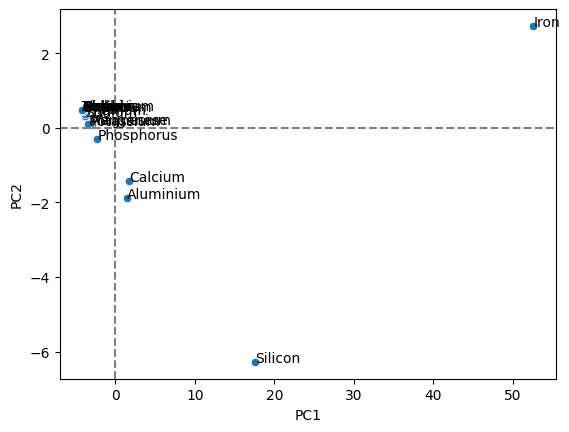

In [41]:
# Your code here...
sns.scatterplot(x='PC1', y='PC2', data=t_pca_table)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
for i in range(len(t_pca_table)):
    plt.text(t_pca_table['PC1'].iloc[i], t_pca_table['PC2'].iloc[i], t_pca_table.index[i])
plt.show()

Which two elements stand out?

**Q14. Assign the names of the elements corresponding to the maximum absolute values of PC1 and PC2 to a variable called `max_values`.**

This should be a `tuple` of the form `(<PC1 max absolute value element>, <PC2 max absolute value element>)`.

In [42]:
# Your code here...
pc1_max_element = t_pca_table['PC1'].abs().idxmax()
pc2_max_element = t_pca_table['PC2'].abs().idxmax()
max_values = (pc1_max_element, pc2_max_element)
max_values

('Iron', 'Silicon')